<a href="https://www.kaggle.com/code/lalit7881/air-quality-eda-100?scriptVersionId=318676820" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lalit7881/air-quality/Air_Quality_and_Health_Impacts.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lalit7881/air-quality/Air_Quality_and_Health_Impacts.csv")

In [3]:
df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,878218,386,Ozone (O3),Mean,ppb,UHF42,402,West Queens,Summer 2023,06/01/2023,34.365989,NaN
1,878245,386,Ozone (O3),Mean,ppb,UHF42,103,Fordham - Bronx Pk,Summer 2023,06/01/2023,32.310518,NaN
2,743686,386,Ozone (O3),Mean,ppb,UHF42,503,Willowbrook,Summer 2021,06/01/2021,29.086208,NaN
3,827060,386,Ozone (O3),Mean,ppb,UHF34,407,Southwest Queens,Summer 2022,06/01/2022,35.155608,NaN
4,825775,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,201,Greenpoint,Summer 2022,06/01/2022,14.068715,NaN


In [4]:
df.tail()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
18857,130891,650,Respiratory hospitalizations due to PM2.5 (age...,Estimated annual rate,"per 100,000 adults",UHF42,202,Downtown - Heights - Slope,2005-2007,01/01/2005,20.700000,NaN
18858,130916,650,Respiratory hospitalizations due to PM2.5 (age...,Estimated annual rate,"per 100,000 adults",UHF42,406,Fresh Meadows,2005-2007,01/01/2005,15.200000,NaN
18859,130760,647,Outdoor Air Toxics - Formaldehyde,Annual average concentration,Âµg/m3,UHF42,310,Lower Manhattan,2005,01/01/2005,4.200000,NaN
18860,130749,647,Outdoor Air Toxics - Formaldehyde,Annual average concentration,Âµg/m3,UHF42,210,Coney Island - Sheepshead Bay,2005,01/01/2005,2.500000,NaN
18861,154604,643,Annual vehicle miles traveled,Million miles,per square mile,CD,403,Jackson Heights (CD3),2005,01/01/2005,64.205163,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [6]:
df.describe()

,Unique ID,Indicator ID,Geo Join ID,Data Value,Message
count,18862.000000,18862.000000,1.886200e+04,18862.000000,0.0
mean,452004.167533,431.817888,5.983262e+05,21.051580,NaN
std,262910.731230,113.946565,7.819721e+06,23.564920,NaN
min,130355.000000,365.000000,1.000000e+00,0.000000,NaN
25%,176073.250000,365.000000,2.020000e+02,8.742004,NaN
50%,412490.500000,375.000000,3.030000e+02,14.790000,NaN
75%,669588.750000,386.000000,4.040000e+02,26.267500,NaN
max,878254.000000,661.000000,1.051061e+08,424.700000,NaN


In [7]:
df.isnull().sum()

Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Start_Date            0
Data Value            0
Message           18862
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Unique ID           int64
Indicator ID        int64
Name               object
Measure            object
Measure Info       object
Geo Type Name      object
Geo Join ID         int64
Geo Place Name     object
Time Period        object
Start_Date         object
Data Value        float64
Message           float64
dtype: object

In [10]:
df.shape

(18862, 12)

In [11]:
df.columns

Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

In [12]:
df.dtypes

Unique ID           int64
Indicator ID        int64
Name               object
Measure            object
Measure Info       object
Geo Type Name      object
Geo Join ID         int64
Geo Place Name     object
Time Period        object
Start_Date         object
Data Value        float64
Message           float64
dtype: object

In [13]:
df.nunique()

Unique ID         18862
Indicator ID         21
Name                 18
Measure               8
Measure Info          8
Geo Type Name         5
Geo Join ID          72
Geo Place Name      114
Time Period          57
Start_Date           46
Data Value         7375
Message               0
dtype: int64

## EDA

Shape of Dataset : (18862, 12)

Columns :
Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

Data Types :
Unique ID                  int64
Indicator ID               int64
Name                      object
Measure                   object
Measure Info              object
Geo Type Name             object
Geo Join ID                int64
Geo Place Name            object
Time Period               object
Start_Date        datetime64[ns]
Data Value               float64
Message                   object
dtype: object


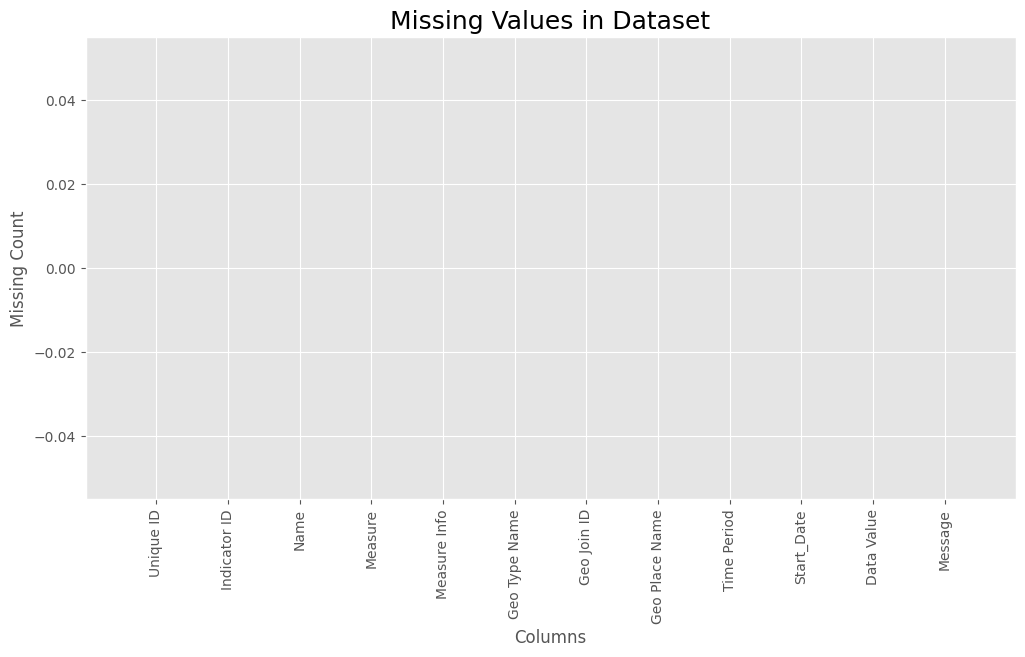

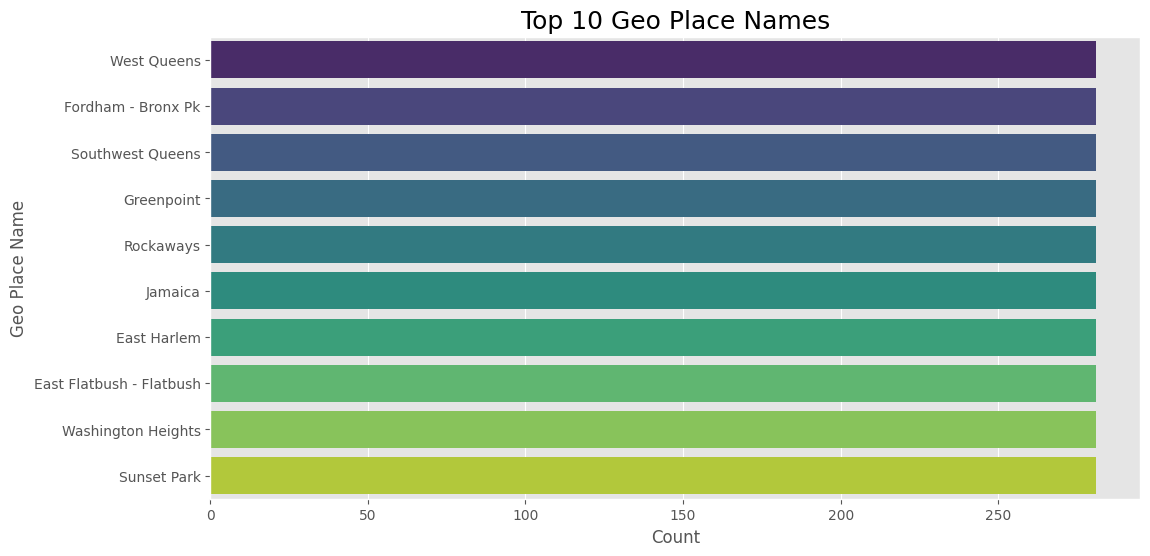

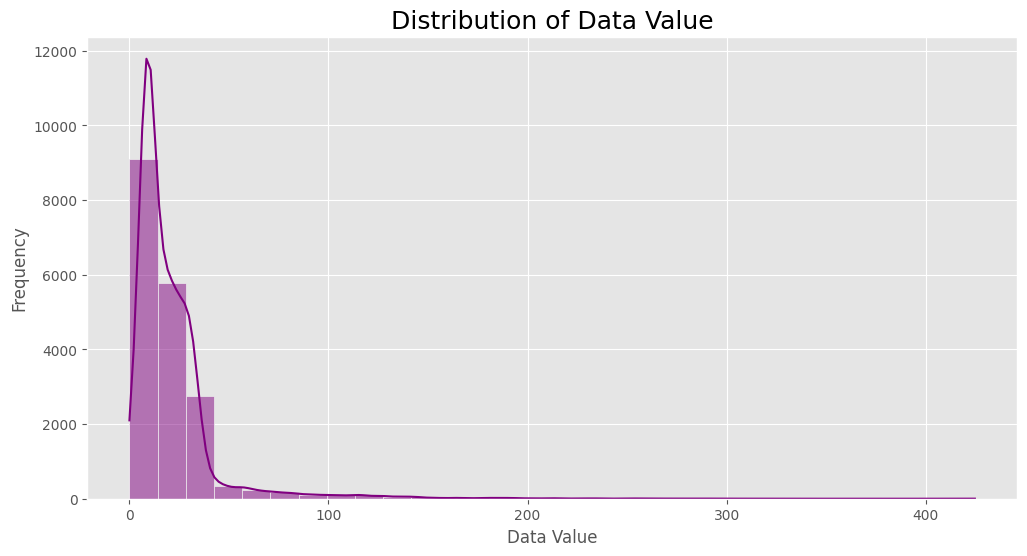

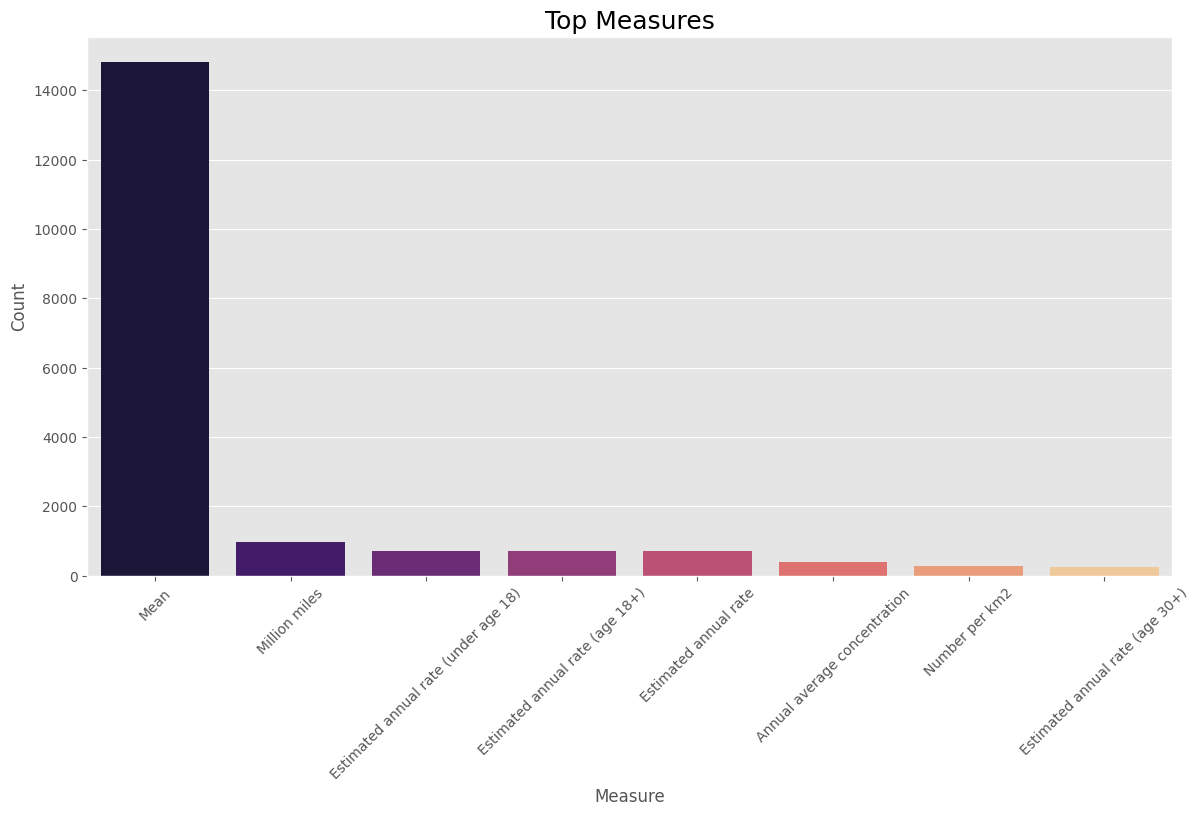

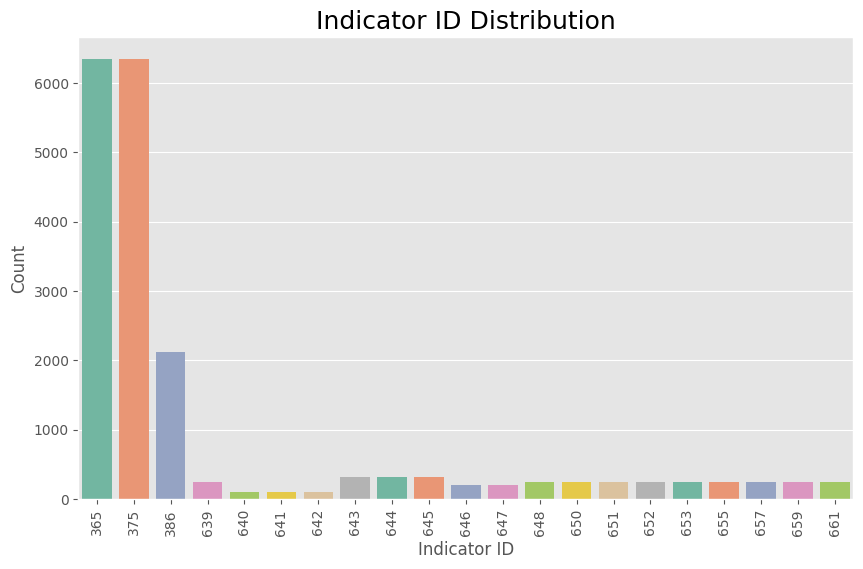

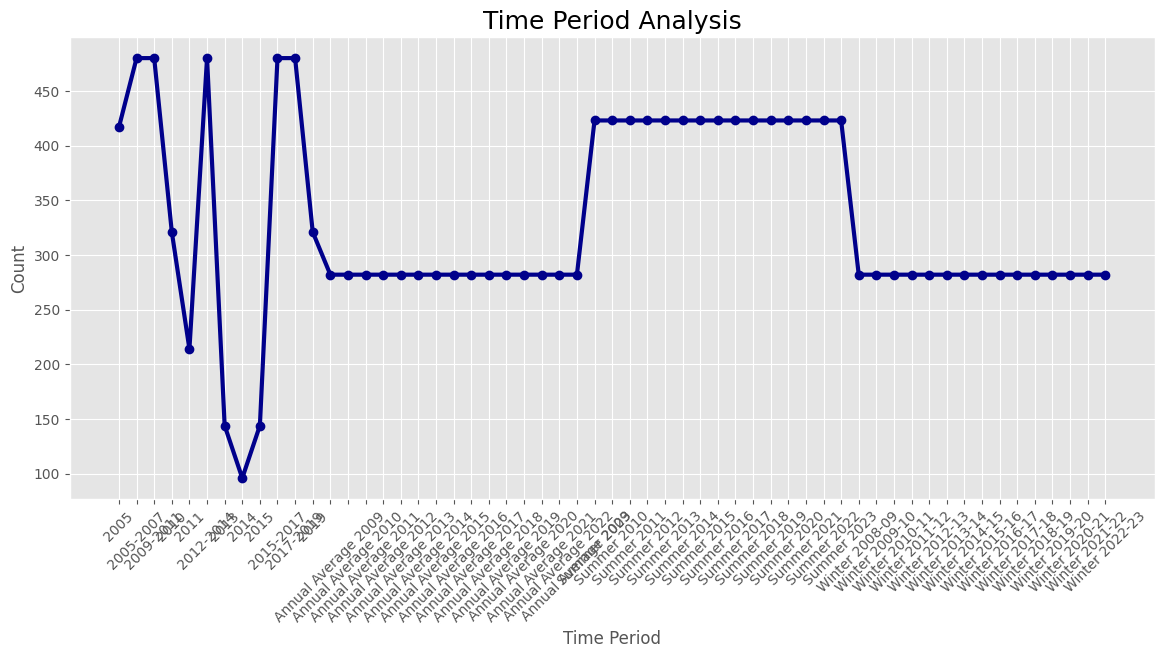

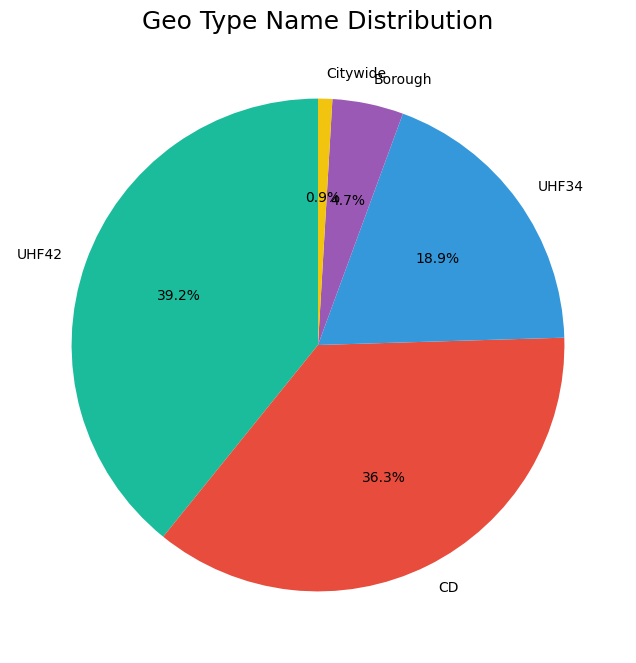

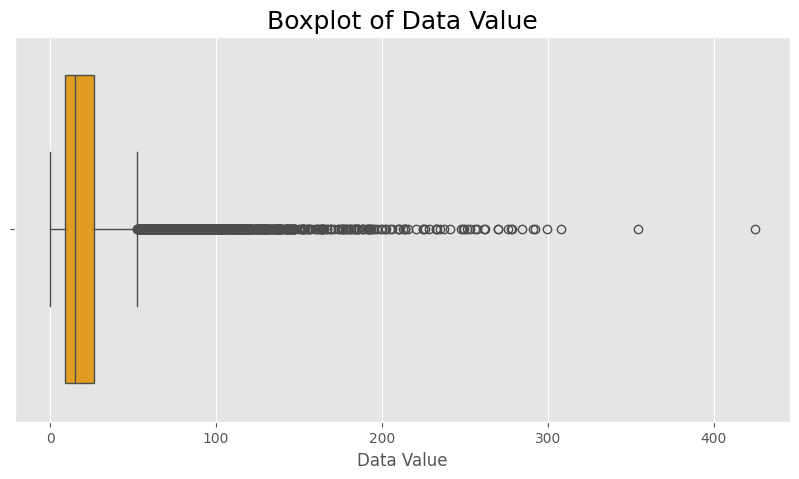

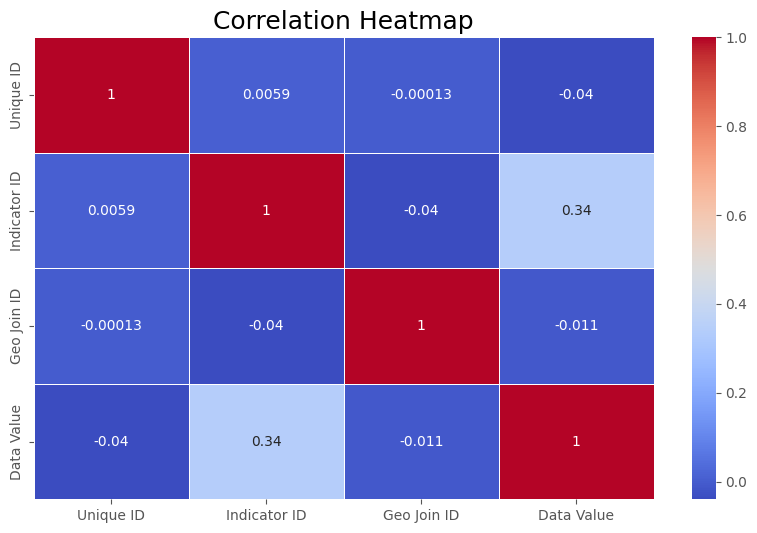

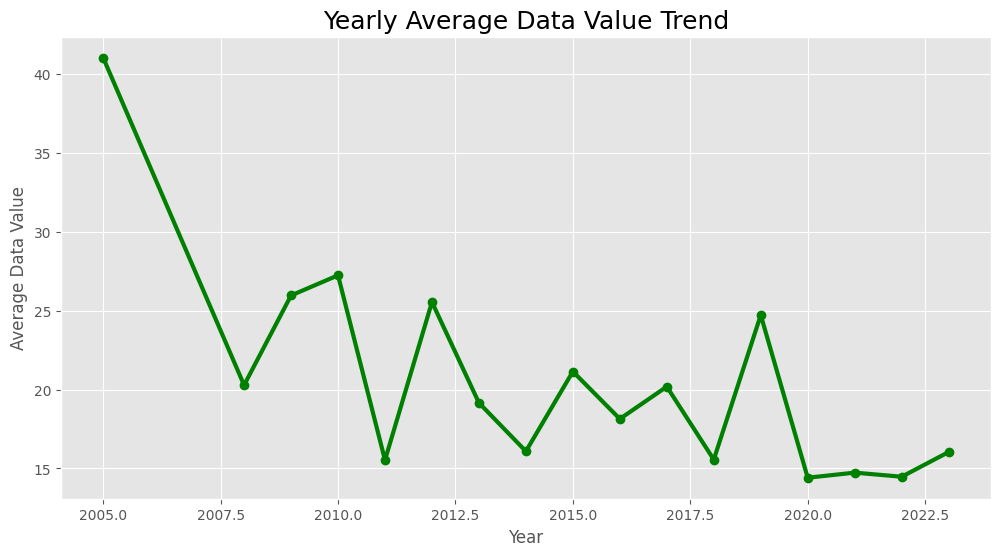

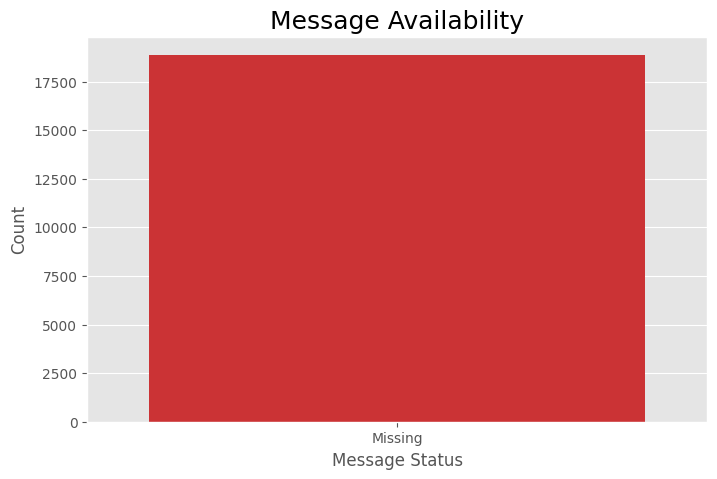

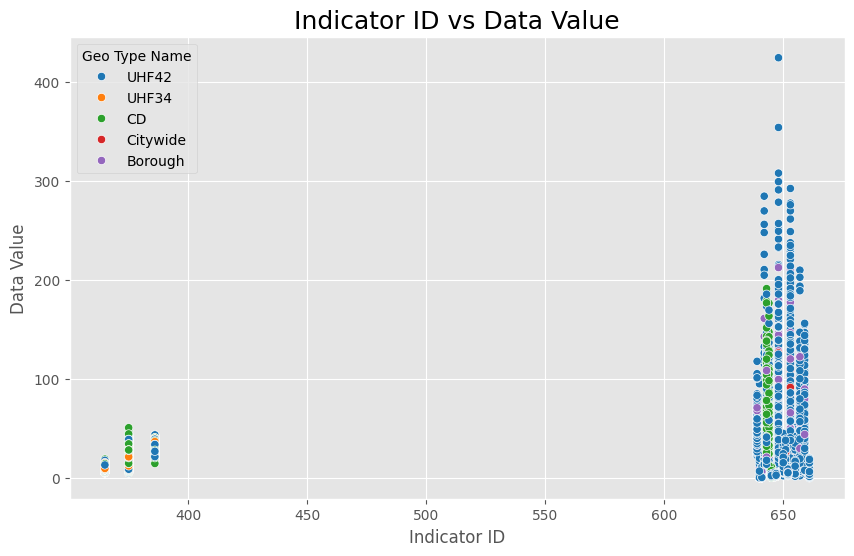

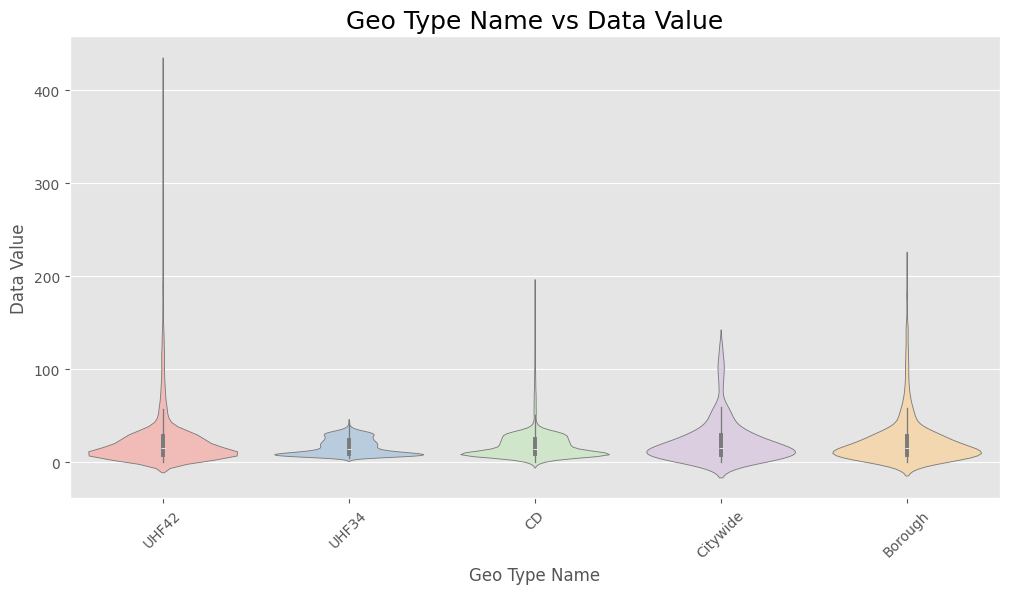

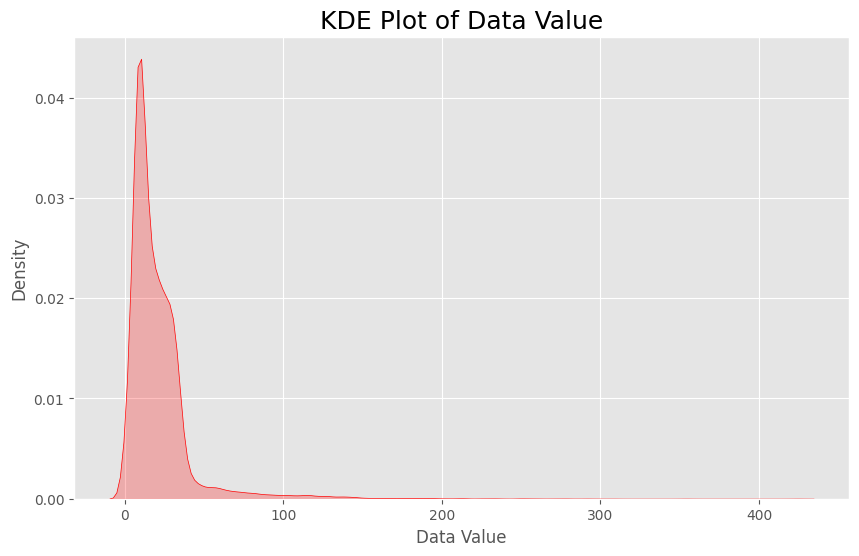

Visualization Completed Successfully


In [14]:
plt.style.use('ggplot')

# Different color palettes
colors1 = ['#FF5733', '#33FF57', '#3357FF', '#F39C12', '#8E44AD']
colors2 = ['#1ABC9C', '#E74C3C', '#3498DB', '#9B59B6', '#F1C40F']
colors3 = ['#2ECC71', '#E67E22', '#34495E', '#16A085', '#C0392B']

# -------------------------------
# DATA CLEANING
# -------------------------------

# Convert date column
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')

# Fill missing values
df['Message'] = df['Message'].fillna('No Message')

# -------------------------------
# DATASET OVERVIEW
# -------------------------------

print("Shape of Dataset :", df.shape)
print("\nColumns :")
print(df.columns)

print("\nData Types :")
print(df.dtypes)

# ================================
# 1. MISSING VALUES VISUALIZATION
# ================================

plt.figure(figsize=(12,6))

missing = df.isnull().sum()

plt.bar(
    missing.index,
    missing.values,
    color=colors1
)

plt.xticks(rotation=90)
plt.title('Missing Values in Dataset', fontsize=18)
plt.xlabel('Columns')
plt.ylabel('Missing Count')

plt.show()

# ================================
# 2. TOP GEO PLACE NAME
# ================================

top_places = df['Geo Place Name'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_places.values,
    y=top_places.index,
    palette='viridis'
)

plt.title('Top 10 Geo Place Names', fontsize=18)
plt.xlabel('Count')
plt.ylabel('Geo Place Name')

plt.show()

# ================================
# 3. DATA VALUE DISTRIBUTION
# ================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Data Value'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title('Distribution of Data Value', fontsize=18)
plt.xlabel('Data Value')
plt.ylabel('Frequency')

plt.show()

# ================================
# 4. MEASURE COUNT PLOT
# ================================

plt.figure(figsize=(14,7))

measure_counts = df['Measure'].value_counts().head(10)

sns.barplot(
    x=measure_counts.index,
    y=measure_counts.values,
    palette='magma'
)

plt.xticks(rotation=45)
plt.title('Top Measures', fontsize=18)
plt.xlabel('Measure')
plt.ylabel('Count')

plt.show()

# ================================
# 5. INDICATOR ID DISTRIBUTION
# ================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='Indicator ID',
    data=df,
    palette='Set2'
)

plt.xticks(rotation=90)

plt.title('Indicator ID Distribution', fontsize=18)
plt.xlabel('Indicator ID')
plt.ylabel('Count')

plt.show()

# ================================
# 6. TIME PERIOD ANALYSIS
# ================================

time_counts = df['Time Period'].value_counts().sort_index()

plt.figure(figsize=(14,6))

plt.plot(
    time_counts.index,
    time_counts.values,
    marker='o',
    linewidth=3,
    color='darkblue'
)

plt.xticks(rotation=45)

plt.title('Time Period Analysis', fontsize=18)
plt.xlabel('Time Period')
plt.ylabel('Count')

plt.grid(True)

plt.show()

# ================================
# 7. PIE CHART OF GEO TYPE NAME
# ================================

geo_counts = df['Geo Type Name'].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    geo_counts.values,
    labels=geo_counts.index,
    autopct='%1.1f%%',
    colors=colors2,
    startangle=90
)

plt.title('Geo Type Name Distribution', fontsize=18)

plt.show()

# ================================
# 8. BOXPLOT OF DATA VALUE
# ================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Data Value'],
    color='orange'
)

plt.title('Boxplot of Data Value', fontsize=18)

plt.show()

# ================================
# 9. HEATMAP OF NUMERICAL FEATURES
# ================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=18)

plt.show()

# ================================
# 10. YEARLY TREND ANALYSIS
# ================================

df['Year'] = df['Start_Date'].dt.year

yearly = df.groupby('Year')['Data Value'].mean()

plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values,
    marker='o',
    color='green',
    linewidth=3
)

plt.title('Yearly Average Data Value Trend', fontsize=18)
plt.xlabel('Year')
plt.ylabel('Average Data Value')

plt.grid(True)

plt.show()

# ================================
# 11. COUNTPLOT OF MESSAGE COLUMN
# ================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=df['Message'].apply(lambda x: 'Available' if x != 'No Message' else 'Missing'),
    palette='Set1'
)

plt.title('Message Availability', fontsize=18)
plt.xlabel('Message Status')
plt.ylabel('Count')

plt.show()

# ================================
# 12. SCATTERPLOT
# ================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Indicator ID',
    y='Data Value',
    hue='Geo Type Name',
    data=df,
    palette='tab10'
)

plt.title('Indicator ID vs Data Value', fontsize=18)

plt.show()

# ================================
# 13. VIOLIN PLOT
# ================================

plt.figure(figsize=(12,6))

sns.violinplot(
    x='Geo Type Name',
    y='Data Value',
    data=df,
    palette='Pastel1'
)

plt.xticks(rotation=45)

plt.title('Geo Type Name vs Data Value', fontsize=18)

plt.show()

# ================================
# 14. KDE PLOT
# ================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    df['Data Value'],
    shade=True,
    color='red'
)

plt.title('KDE Plot of Data Value', fontsize=18)

plt.show()

# ================================
# END
# ================================

print("Visualization Completed Successfully")

## Feature engineering

Dataset Shape : (18862, 13)

Target Distribution:
Target
1    9432
0    9430
Name: count, dtype: int64

Categorical Columns:
['Name', 'Measure', 'Measure Info', 'Geo Type Name', 'Geo Place Name', 'Time Period', 'Message']

Numerical Columns:
['Unique ID', 'Indicator ID', 'Geo Join ID', 'Data Value']

Train Shape : (15089, 14)
Test Shape  : (3773, 14)


MODEL : Logistic Regression

Accuracy Score :
98.75 %

Classification Report :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1886
           1       0.99      0.99      0.99      1887

    accuracy                           0.99      3773
   macro avg       0.99      0.99      0.99      3773
weighted avg       0.99      0.99      0.99      3773


Confusion Matrix :
[[1863   23]
 [  24 1863]]


<Figure size 1200x800 with 0 Axes>

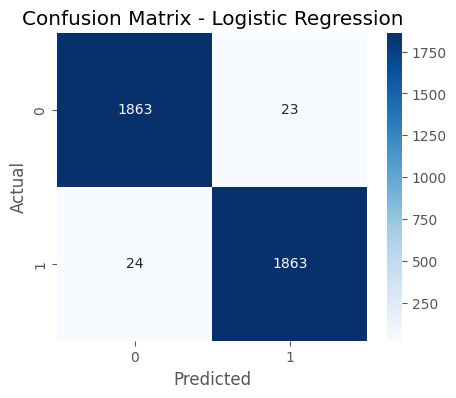



MODEL : Decision Tree

Accuracy Score :
100.0 %

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1886
           1       1.00      1.00      1.00      1887

    accuracy                           1.00      3773
   macro avg       1.00      1.00      1.00      3773
weighted avg       1.00      1.00      1.00      3773


Confusion Matrix :
[[1886    0]
 [   0 1887]]


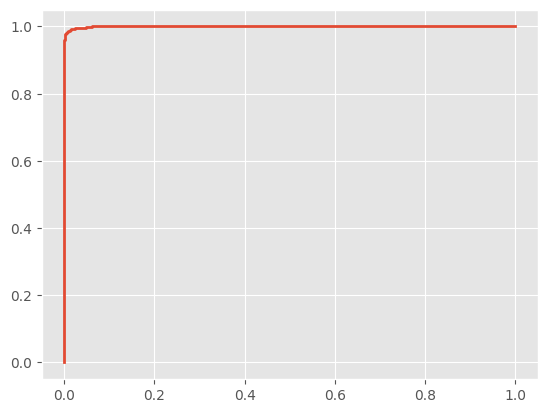

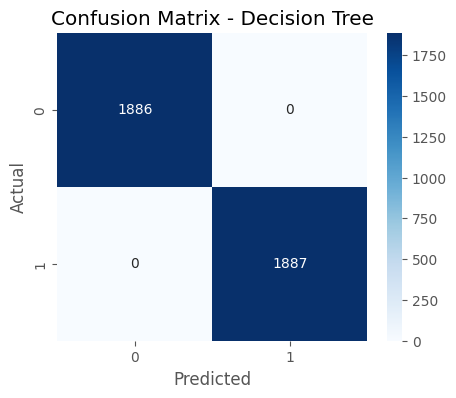



MODEL : Random Forest

Accuracy Score :
100.0 %

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1886
           1       1.00      1.00      1.00      1887

    accuracy                           1.00      3773
   macro avg       1.00      1.00      1.00      3773
weighted avg       1.00      1.00      1.00      3773


Confusion Matrix :
[[1886    0]
 [   0 1887]]


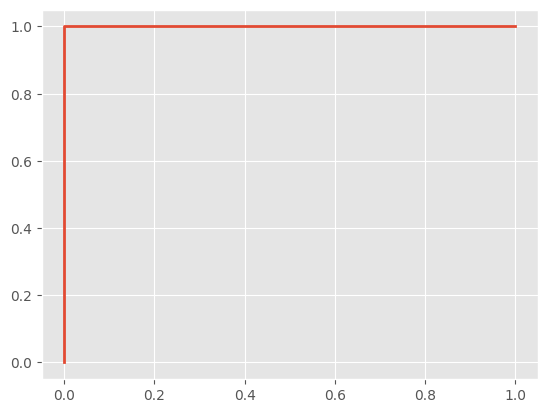

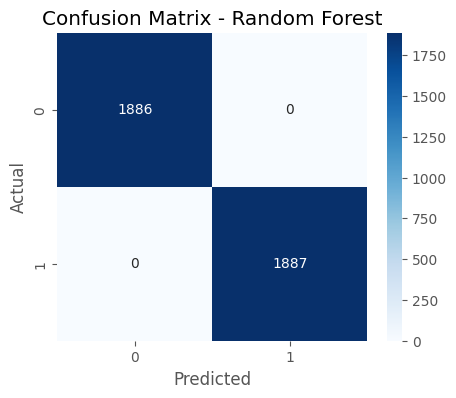



MODEL : Gradient Boosting

Accuracy Score :
100.0 %

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1886
           1       1.00      1.00      1.00      1887

    accuracy                           1.00      3773
   macro avg       1.00      1.00      1.00      3773
weighted avg       1.00      1.00      1.00      3773


Confusion Matrix :
[[1886    0]
 [   0 1887]]


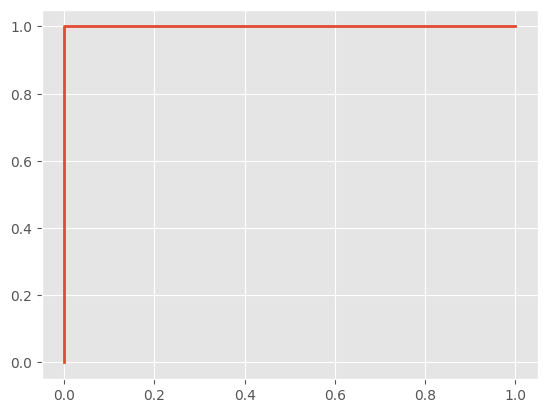

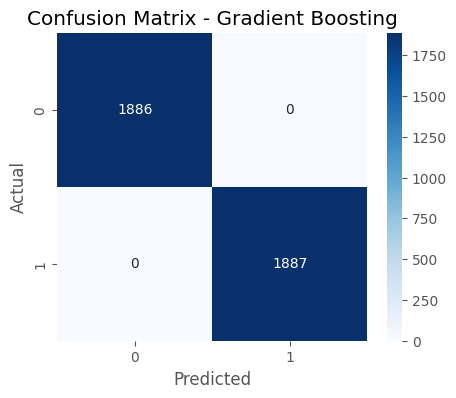



MODEL : KNN

Accuracy Score :
98.54 %

Classification Report :
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1886
           1       0.98      0.99      0.99      1887

    accuracy                           0.99      3773
   macro avg       0.99      0.99      0.99      3773
weighted avg       0.99      0.99      0.99      3773


Confusion Matrix :
[[1855   31]
 [  24 1863]]


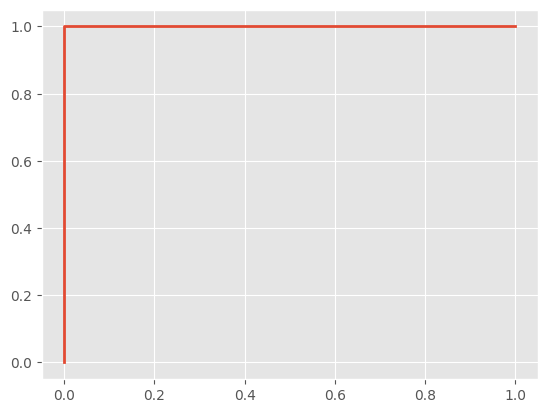

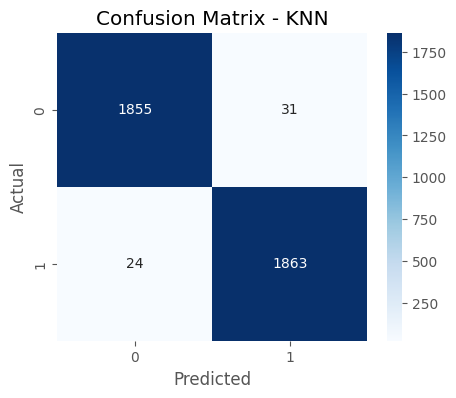



MODEL : SVM

Accuracy Score :
97.85 %

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1886
           1       0.97      0.98      0.98      1887

    accuracy                           0.98      3773
   macro avg       0.98      0.98      0.98      3773
weighted avg       0.98      0.98      0.98      3773


Confusion Matrix :
[[1834   52]
 [  29 1858]]


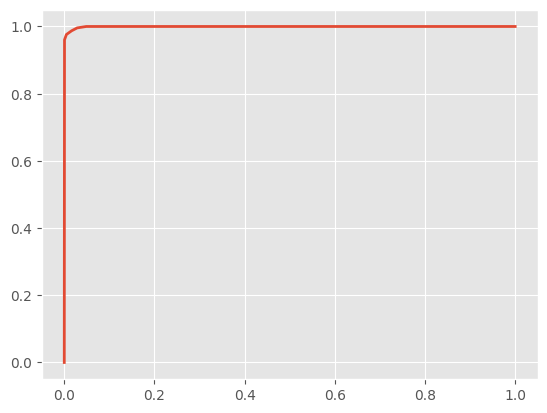

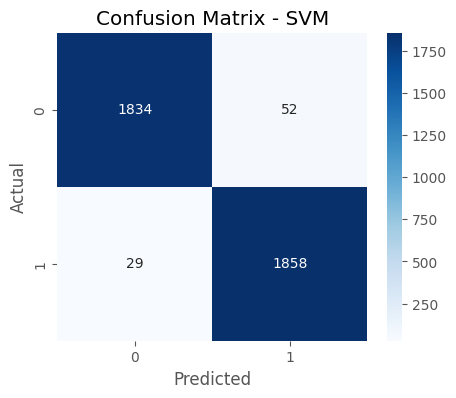

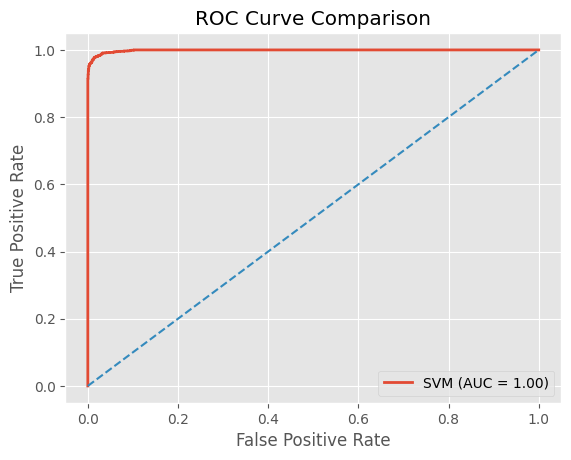



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
1        Decision Tree  1.000000  1.000000
2        Random Forest  1.000000  1.000000
3    Gradient Boosting  1.000000  1.000000
0  Logistic Regression  0.987543  0.999530
4                  KNN  0.985423  0.999230
5                  SVM  0.978532  0.998743


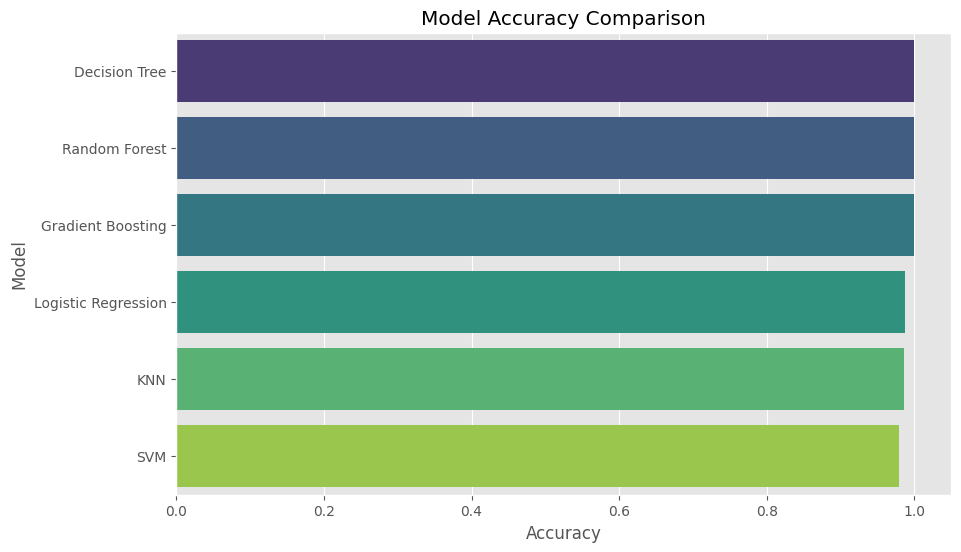

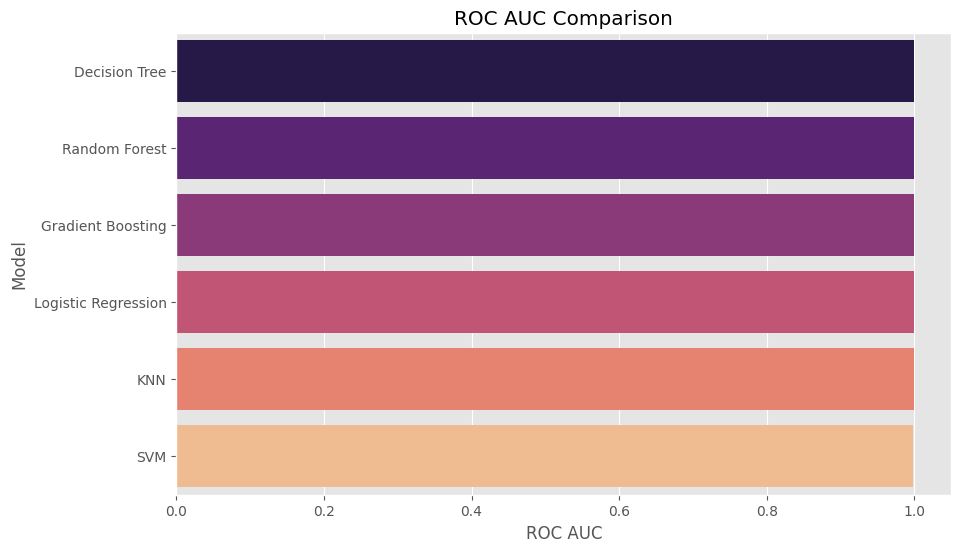


Best Performing Model :
Model       Decision Tree
Accuracy              1.0
ROC_AUC               1.0
Name: 1, dtype: object

Machine Learning Pipeline Completed Successfully


In [15]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


print("Dataset Shape :", df.shape)

# ==========================================
# DATA CLEANING
# ==========================================

# Fill missing message values
df['Message'] = df['Message'].fillna('No Message')

# Convert date column
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')

# Create extra date features
df['Year'] = df['Start_Date'].dt.year
df['Month'] = df['Start_Date'].dt.month
df['Day'] = df['Start_Date'].dt.day

# Drop original date column
df.drop('Start_Date', axis=1, inplace=True)

# ==========================================
# TARGET COLUMN
# ==========================================

# Convert target into categories
# Example: High / Low based on median

median_value = df['Data Value'].median()

df['Target'] = np.where(
    df['Data Value'] >= median_value,
    1,
    0
)

print("\nTarget Distribution:")
print(df['Target'].value_counts())

# ==========================================
# FEATURE & TARGET SPLIT
# ==========================================

X = df.drop(['Target'], axis=1)
y = df['Target']

# ==========================================
# IDENTIFY COLUMN TYPES
# ==========================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# ==========================================
# PREPROCESSING PIPELINE
# ==========================================

# Numerical transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

# ==========================================
# MACHINE LEARNING MODELS
# ==========================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(
        probability=True
    )
}

# ==========================================
# TRAINING & EVALUATION
# ==========================================

results = []

plt.figure(figsize=(12,8))

for name, model in models.items():

    print("\n")
    print("="*60)
    print("MODEL :", name)
    print("="*60)

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print("\nAccuracy Score :")
    print(round(accuracy * 100, 2), "%")

    # Classification Report
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix :")
    print(cm)

    # Heatmap
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # ROC Curve
    y_prob = pipeline.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    # Store results
    results.append([name, accuracy, auc_score])

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc_score:.2f})'
    )

# ==========================================
# FINAL ROC CURVE
# ==========================================

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# RESULTS TABLE
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'ROC_AUC']
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n")
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(results_df)

# ==========================================
# BARPLOT OF ACCURACY
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')

plt.show()

# ==========================================
# BARPLOT OF ROC AUC
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df,
    palette='magma'
)

plt.title('ROC AUC Comparison')
plt.xlabel('ROC AUC')
plt.ylabel('Model')

plt.show()

# ==========================================
# BEST MODEL
# ==========================================

best_model = results_df.iloc[0]

print("\nBest Performing Model :")
print(best_model)

# ==========================================
# END
# ==========================================

print("\nMachine Learning Pipeline Completed Successfully")

## Thank you......pls upvote!!!!!!!!!!!!!!